In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     print(f'{dirname} - {len(filenames)}')

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
TRAIN_PATH='/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/'
VAL_PATH='/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/'
TEST_PATH='/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred/'

In [3]:
len(os.listdir(TRAIN_PATH)),len(os.listdir(VAL_PATH)),len(os.listdir(TEST_PATH))

(6, 6, 7301)

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

In [5]:
targets = os.listdir(TRAIN_PATH)
targets

['mountain', 'street', 'buildings', 'sea', 'forest', 'glacier']

In [6]:
IMG_DIM=224

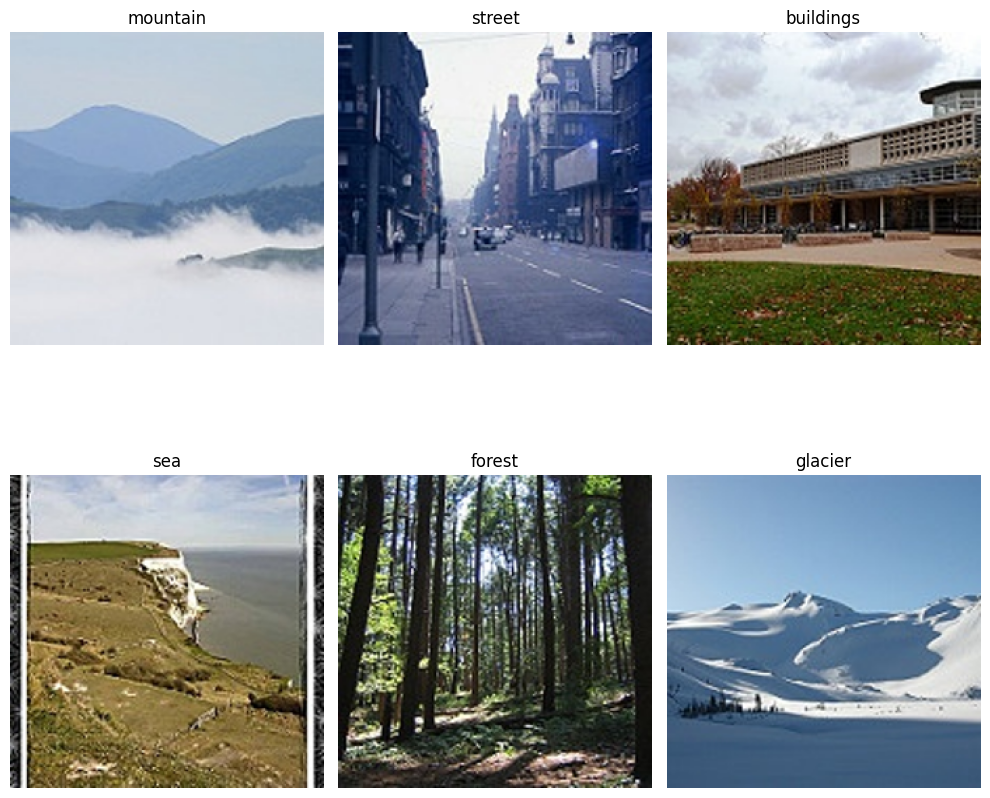

In [7]:
fig, ax = plt.subplots(2, 3, figsize=(10,10))

for axis, target in zip(ax.ravel(), targets):
    class_dir = os.path.join(TRAIN_PATH, target)

    img_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_name)

    img = Image.open(img_path)
    img = img.resize((IMG_DIM, IMG_DIM))

    axis.imshow(img)
    axis.set_title(target)
    axis.axis("off")

plt.tight_layout()
plt.show()

In [8]:
class_to_idx = {
    cls_name: idx
    for idx, cls_name in enumerate(sorted(targets))
}
idx_to_class = {
    idx: cls
    for idx, cls in enumerate(sorted(targets))    
}
idx_to_class, class_to_idx

({0: 'buildings',
  1: 'forest',
  2: 'glacier',
  3: 'mountain',
  4: 'sea',
  5: 'street'},
 {'buildings': 0,
  'forest': 1,
  'glacier': 2,
  'mountain': 3,
  'sea': 4,
  'street': 5})

In [9]:
class TrainValDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {
            cls_name: idx
            for idx, cls_name in enumerate(self.classes)
        }

        self.samples = []  # list of (img_path, classIdx)

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)

            for img_name in os.listdir(cls_dir):
                img_path = os.path.join(cls_dir, img_name)

                self.samples.append(
                    (img_path, self.class_to_idx[cls_name])
                )


    def __len__(self):
        return len(self.samples)
        

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [10]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.samples = []  # list of img_path
        for img_path in os.listdir(self.root_dir):
            self.samples.append(os.path.join(root_dir, img_path))

    def __len__(self):
        return len(self.samples)
        

    def __getitem__(self, idx):
        img_path = self.samples[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img

In [11]:
train_tranform = transforms.Compose([
    # transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.RandomResizedCrop(IMG_DIM),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_val_transform = transforms.Compose([
    transforms.Resize((IMG_DIM, IMG_DIM)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [12]:
train_ds = TrainValDataset(TRAIN_PATH, train_tranform)
val_ds = TrainValDataset(TRAIN_PATH, test_val_transform)
test_ds = TestDataset(TEST_PATH, test_val_transform)

In [13]:
batch_size=64

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size)
test_loader = DataLoader(test_ds, batch_size=batch_size)

In [14]:
images, labels = next(iter(train_loader))
images.shape, labels

(torch.Size([64, 3, 224, 224]),
 tensor([4, 0, 4, 4, 1, 3, 5, 3, 4, 3, 4, 1, 4, 2, 4, 1, 4, 2, 3, 1, 3, 0, 5, 1,
         2, 1, 5, 4, 0, 3, 2, 0, 4, 5, 4, 2, 1, 0, 4, 3, 4, 5, 5, 1, 3, 5, 4, 2,
         3, 3, 1, 1, 1, 4, 1, 5, 1, 1, 4, 5, 4, 2, 0, 1]))

In [15]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # 224-3+2 + 1 = 224
            nn.Conv2d(3, 64, kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # 64,112,112
            nn.Conv2d(64, 128, kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # 128,56,56
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # 256,28,28
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # 512,14,14
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # 512,7,7
        )
        self.linear = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            
            nn.Linear(4096, 1000),
            nn.ReLU(),
            
            nn.Linear(1000, 6),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        x = self.linear(x)        
        return x

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [17]:
net = Network()

net = net.to(device)

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=0.001, weight_decay=1e-4)

In [19]:
epochs = 100
best_val_loss = float("inf")
patience = 10
counter = 0

In [21]:
for epoch in range(epochs):
    running_loss = 0.0
    
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
    train_loss = running_loss / len(train_loader)

    # val
    net.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()

            total += labels.size(0)
            
    val_loss /= len(val_loader)
    accuracy = correct / total
    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {accuracy:.2f}%"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # counter = 0
        torch.save(
            net.state_dict(),
            "best_model.pth"
        )

    else:
        counter += 1

    if counter >= patience:
        print("Early Stopping")
        break

Epoch [1/100] Train Loss: 1.2940 Val Loss: 0.9045 Val Acc: 0.64%
Epoch [2/100] Train Loss: 1.0835 Val Loss: 0.8824 Val Acc: 0.64%
Epoch [3/100] Train Loss: 0.9416 Val Loss: 0.6739 Val Acc: 0.75%
Epoch [4/100] Train Loss: 0.8553 Val Loss: 0.6545 Val Acc: 0.77%
Epoch [5/100] Train Loss: 0.7942 Val Loss: 0.6071 Val Acc: 0.77%
Epoch [6/100] Train Loss: 0.7564 Val Loss: 0.5716 Val Acc: 0.80%
Epoch [7/100] Train Loss: 0.7281 Val Loss: 0.5045 Val Acc: 0.82%
Epoch [8/100] Train Loss: 0.6886 Val Loss: 0.4907 Val Acc: 0.82%
Epoch [9/100] Train Loss: 0.6915 Val Loss: 0.4638 Val Acc: 0.83%
Epoch [10/100] Train Loss: 0.6610 Val Loss: 0.5152 Val Acc: 0.82%
Epoch [11/100] Train Loss: 0.6558 Val Loss: 0.4359 Val Acc: 0.84%
Epoch [12/100] Train Loss: 0.6364 Val Loss: 0.4274 Val Acc: 0.85%
Epoch [13/100] Train Loss: 0.6128 Val Loss: 0.4163 Val Acc: 0.85%
Epoch [14/100] Train Loss: 0.6037 Val Loss: 0.4292 Val Acc: 0.85%
Epoch [15/100] Train Loss: 0.5853 Val Loss: 0.3732 Val Acc: 0.87%
Epoch [16/100] Trai

In [22]:
net.load_state_dict(
    torch.load(
        "/kaggle/working/best_model.pth",
        map_location=device
    )
)

model = net.to(device)

In [23]:
net.eval()
correct, total = 0,0

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = net(imgs)
        preds = outputs.argmax(dim=1)
        
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct/total
print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 0.89%


In [24]:
next(iter(test_loader))[0].shape, len(next(iter(test_loader)))

(torch.Size([3, 224, 224]), 64)

In [25]:
net.eval()

imgs = next(iter(test_loader))
with torch.no_grad():
    outputs = net(imgs.to(device))
    preds = outputs.argmax(dim=1).cpu()

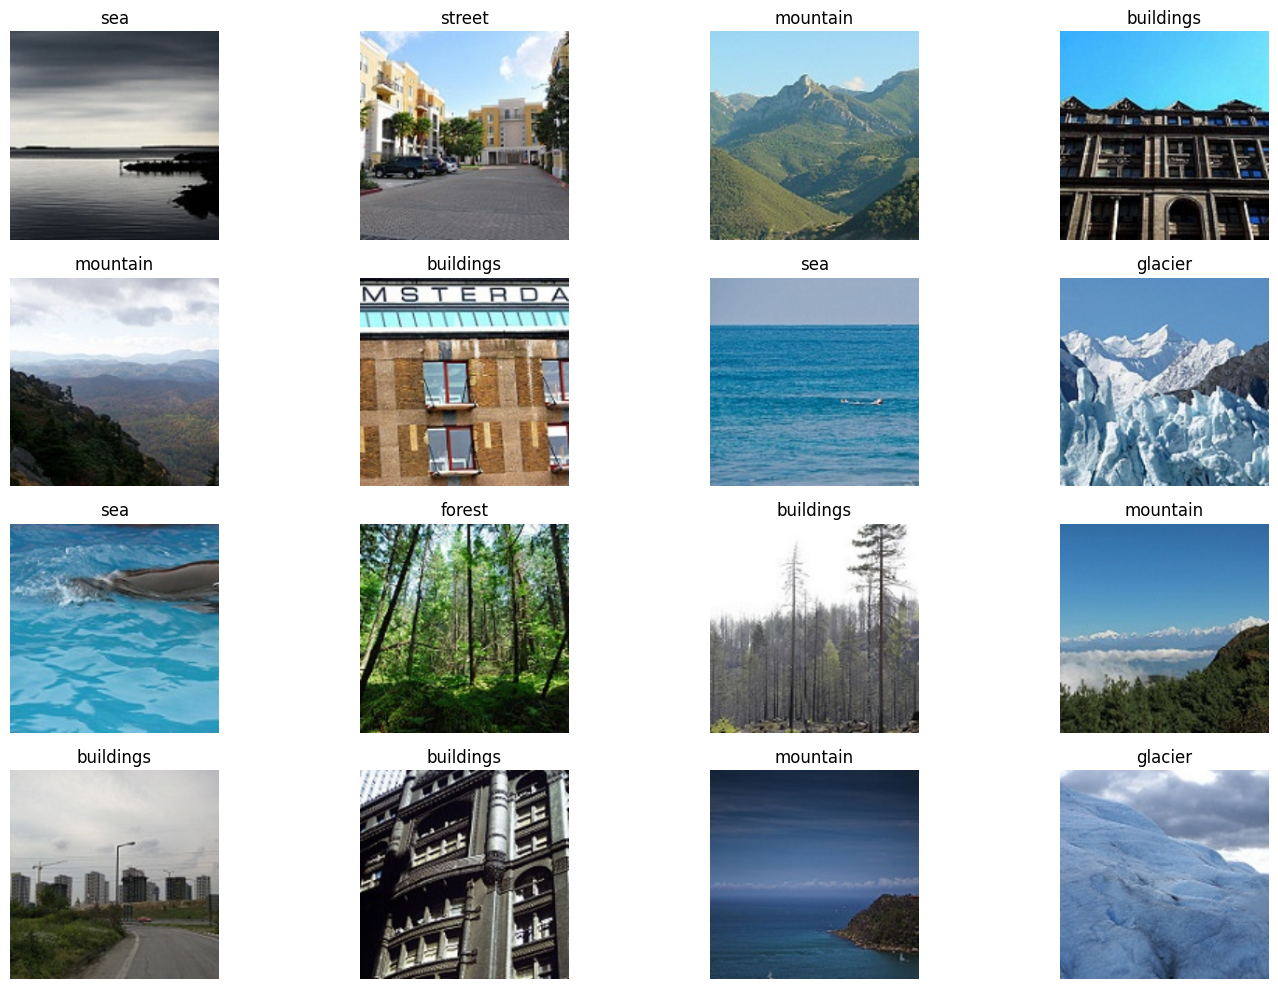

In [26]:
fig, axes = plt.subplots(4, 4, figsize=(15, 10))

for i, ax in enumerate(axes.ravel()):
    img = imgs[i]

    # Undo normalization
    img = img.permute(1, 2, 0)
    img = img * torch.tensor([0.229, 0.224, 0.225]) + \
          torch.tensor([0.485, 0.456, 0.406])

    img = img.clamp(0, 1)

    ax.imshow(img)
    ax.set_title((sorted(targets))[preds[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()